<a href="https://colab.research.google.com/github/srijabiswas-01/Sales-Dashboard-PowerBI/blob/main/Sales-Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn statsmodels

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
df = pd.read_csv(
    "/content/Sample_Superstore.csv",
    encoding="latin1"
)

print("Dataset Loaded Successfully")
display(df.head())

Dataset Loaded Successfully


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [6]:
# Standardise column names
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
              .str.replace("-", "_")
)

df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

In [7]:
# Convert dates
df["order_date"] = pd.to_datetime(df["order_date"], format="%m/%d/%Y")
df["ship_date"] = pd.to_datetime(df["ship_date"], format="%m/%d/%Y")

# Feature engineering
df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.month
df["shipping_delay"] = (df["ship_date"] - df["order_date"]).dt.days

df[["order_year", "order_month", "shipping_delay"]].head()

,order_year,order_month,shipping_delay
0,2016,11,3
1,2016,11,3
2,2016,6,4
3,2015,10,7
4,2015,10,7


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   row_id          9994 non-null   int64         
 1   order_id        9994 non-null   object        
 2   order_date      9994 non-null   datetime64[ns]
 3   ship_date       9994 non-null   datetime64[ns]
 4   ship_mode       9994 non-null   object        
 5   customer_id     9994 non-null   object        
 6   customer_name   9994 non-null   object        
 7   segment         9994 non-null   object        
 8   country         9994 non-null   object        
 9   city            9994 non-null   object        
 10  state           9994 non-null   object        
 11  postal_code     9994 non-null   int64         
 12  region          9994 non-null   object        
 13  product_id      9994 non-null   object        
 14  category        9994 non-null   object        
 15  sub_

**Sales Trend Over Time**

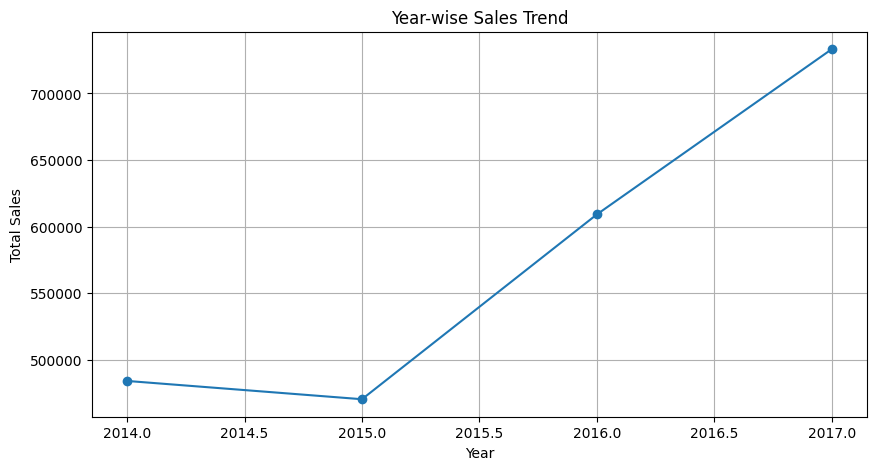

In [9]:
plt.figure(figsize=(10,5))
df.groupby("order_year")["sales"].sum().plot(marker="o")
plt.title("Year-wise Sales Trend")
plt.ylabel("Total Sales")
plt.xlabel("Year")
plt.grid(True)
plt.show()

**Discount vs Profit**

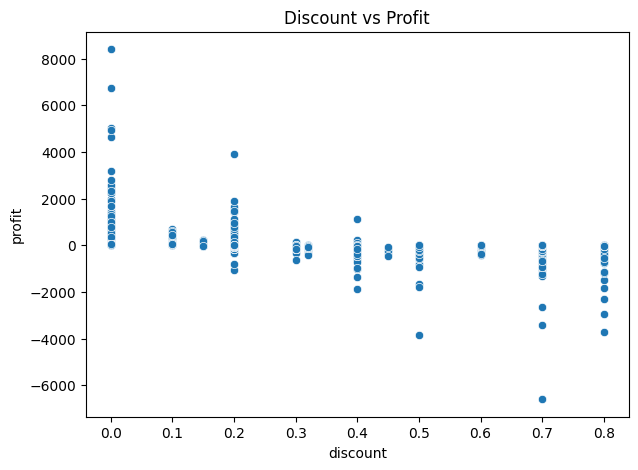

In [10]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="discount", y="profit", data=df)
plt.title("Discount vs Profit")
plt.show()

**Category & Segment Performance**

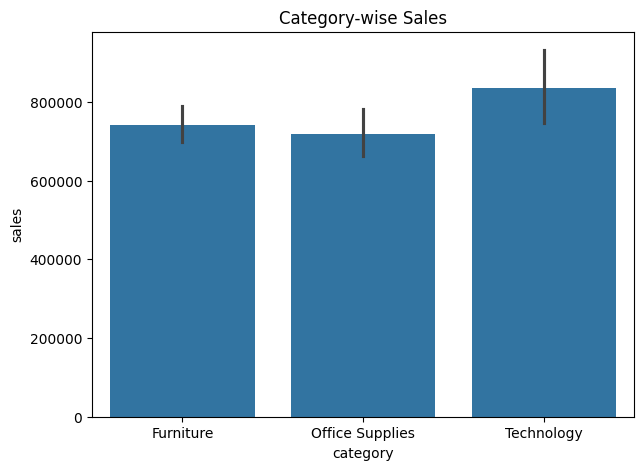

In [11]:
plt.figure(figsize=(7,5))
sns.barplot(x="category", y="sales", data=df, estimator=sum)
plt.title("Category-wise Sales")
plt.show()

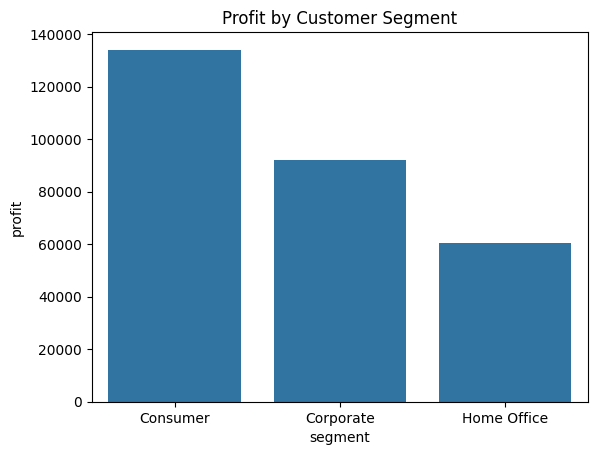

In [12]:
segment_summary = df.groupby("segment")[["sales", "profit"]].sum().reset_index()
sns.barplot(x="segment", y="profit", data=segment_summary)
plt.title("Profit by Customer Segment")
plt.show()

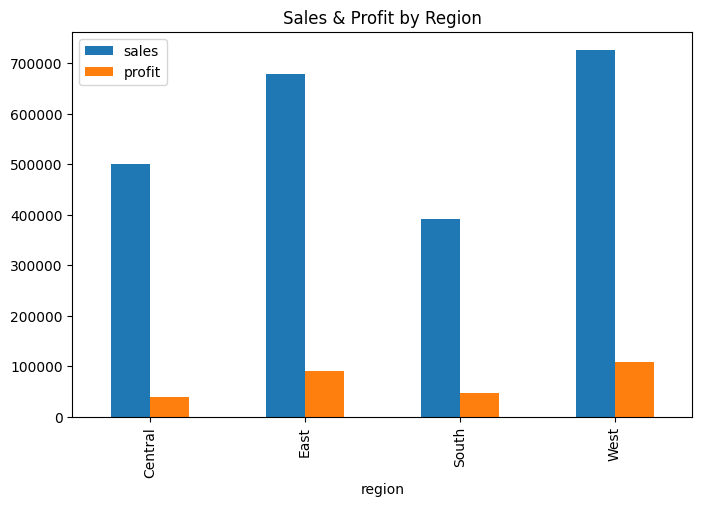

In [13]:
region_summary = df.groupby("region")[["sales", "profit"]].sum().reset_index()
region_summary.plot(
    x="region", y=["sales", "profit"], kind="bar", figsize=(8,5)
)
plt.title("Sales & Profit by Region")
plt.show()

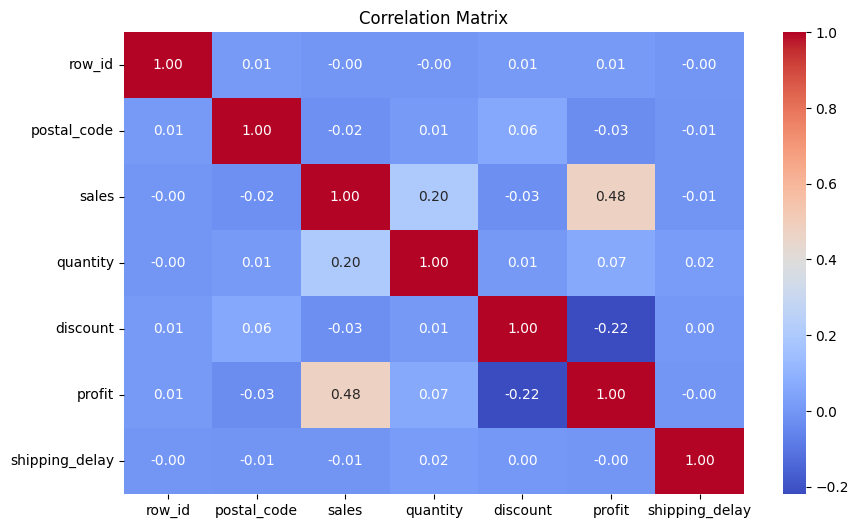

In [16]:
numeric_cols = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

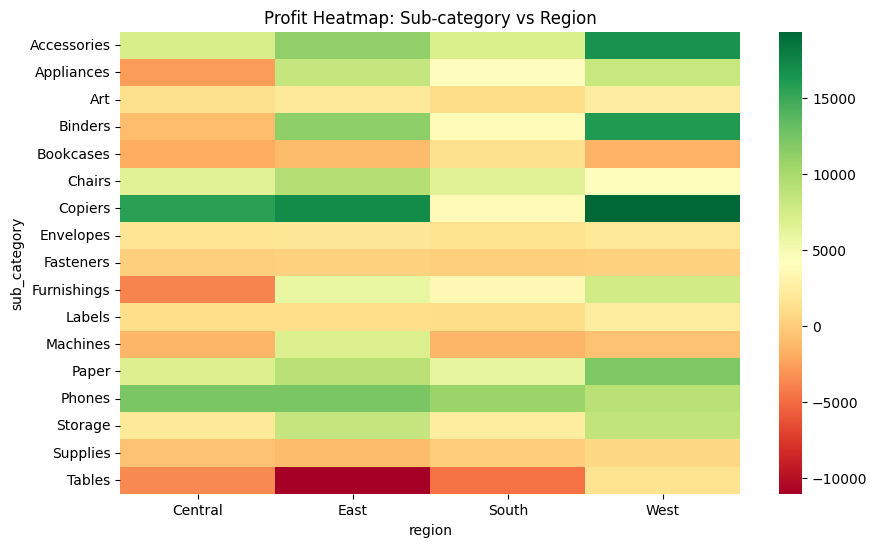

In [17]:
pivot_subcat = df.pivot_table(
    values="profit", index="sub_category", columns="region", aggfunc="sum"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_subcat, cmap="RdYlGn")
plt.title("Profit Heatmap: Sub-category vs Region")
plt.show()

In [18]:
print("Regions:", df["region"].unique())
print("Categories:", df["category"].unique())

user_region = input("Enter Region (or All): ")
user_category = input("Enter Category (or All): ")

filtered_df = df.copy()

if user_region != "All":
    filtered_df = filtered_df[filtered_df["region"] == user_region]

if user_category != "All":
    filtered_df = filtered_df[filtered_df["category"] == user_category]

print("Filtered Records:", filtered_df.shape[0])
display(filtered_df.head())

Regions: ['South' 'West' 'Central' 'East']
Categories: ['Furniture' 'Office Supplies' 'Technology']
Enter Region (or All): South
Enter Category (or All): Technology
Filtered Records: 293


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,category,sub_category,product_name,sales,quantity,discount,profit,order_year,order_month,shipping_delay
106,107,CA-2017-119004,2017-11-23,2017-11-28,Standard Class,JM-15250,Janet Martin,Consumer,United States,Charlotte,...,Technology,Accessories,Memorex Mini Travel Drive 8 GB USB 2.0 Flash D...,74.112,8,0.2,17.6016,2017,11,5
107,108,CA-2017-119004,2017-11-23,2017-11-28,Standard Class,JM-15250,Janet Martin,Consumer,United States,Charlotte,...,Technology,Phones,Speck Products Candyshell Flip Case,27.992,1,0.2,2.0994,2017,11,5
182,183,CA-2014-158274,2014-11-19,2014-11-24,Second Class,RM-19675,Robert Marley,Home Office,United States,Monroe,...,Technology,Phones,AT&T TR1909W,503.960,4,0.0,131.0296,2014,11,5
183,184,CA-2014-158274,2014-11-19,2014-11-24,Second Class,RM-19675,Robert Marley,Home Office,United States,Monroe,...,Technology,Phones,Nokia Lumia 521 (T-Mobile),149.950,5,0.0,41.9860,2014,11,5
184,185,CA-2014-158274,2014-11-19,2014-11-24,Second Class,RM-19675,Robert Marley,Home Office,United States,Monroe,...,Technology,Accessories,HP Standard 104 key PS/2 Keyboard,29.000,2,0.0,7.2500,2014,11,5


In [19]:
# Binary target
df["profit_flag"] = df["profit"].apply(lambda x: 1 if x > 0 else 0)

from sklearn.preprocessing import LabelEncoder

categorical_cols = ["ship_mode", "segment", "region", "category", "sub_category"]

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [21]:
X_cls = df[["sales", "quantity", "discount", "shipping_delay", "region", "category", "segment"]]
y_cls = df["profit_flag"]

X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.943471735867934
              precision    recall  f1-score   support

           0       0.99      0.71      0.83       377
           1       0.94      1.00      0.97      1622

    accuracy                           0.94      1999
   macro avg       0.96      0.85      0.90      1999
weighted avg       0.95      0.94      0.94      1999



In [22]:
X_reg = df[["quantity", "discount", "shipping_delay", "region", "category", "segment"]]
y_reg = df["sales"]

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)
print("R² Score:", r2_score(y_test, pred))

R² Score: -0.0033950650894580825


In [23]:
monthly_sales = (
    df.set_index("order_date")
      .resample("MS")["sales"]
      .sum()
)

train_size = int(len(monthly_sales) * 0.8)
train_ts = monthly_sales[:train_size]
test_ts = monthly_sales[train_size:]

arima = ARIMA(train_ts, order=(1,1,1))
arima_fit = arima.fit()

forecast = arima_fit.forecast(steps=len(test_ts))
forecast.index = test_ts.index

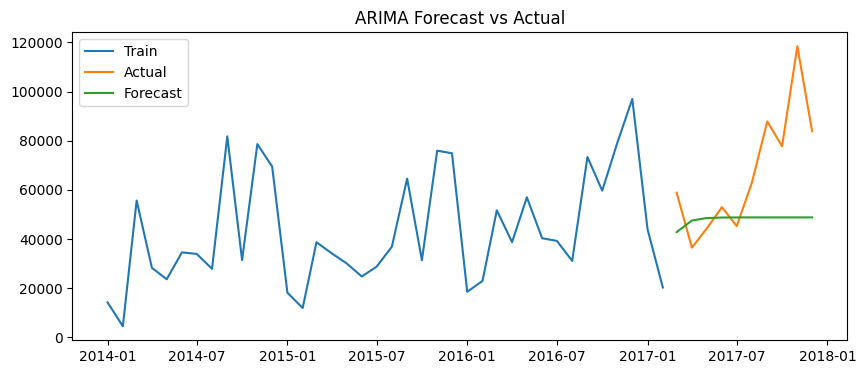

In [24]:
plt.figure(figsize=(10,4))
plt.plot(train_ts, label="Train")
plt.plot(test_ts, label="Actual")
plt.plot(forecast, label="Forecast")
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

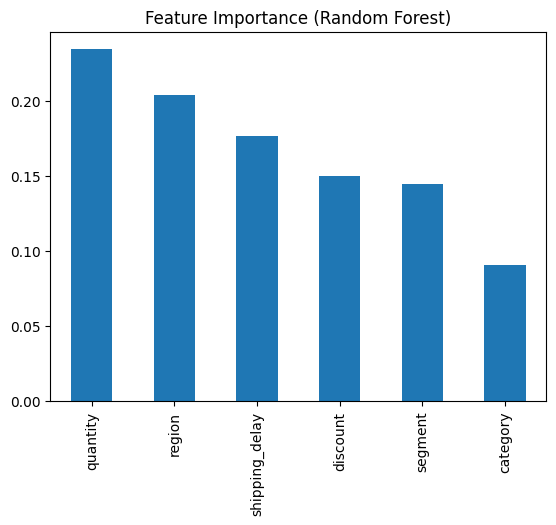

In [26]:
importances = pd.Series(rf.feature_importances_, index=X_reg.columns)
importances.sort_values(ascending=False).plot(kind="bar")
plt.title("Feature Importance (Random Forest)")
plt.show()

In [28]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42)
}

results = []

for name, m in models.items():
    m.fit(X_train, y_train)
    p = m.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, p),
        "RMSE": np.sqrt(mean_squared_error(y_test, p)),  # ✅ FIX
        "R2": r2_score(y_test, p)
    })

regression_results = pd.DataFrame(results)
display(regression_results)

,Model,MAE,RMSE,R2
0,Linear Regression,276.012925,753.798346,0.038069
1,Random Forest,257.541637,769.873123,-0.003395
